# **REDES NEURONALES - REGULARIZACION**

Apellido y Nombre: Vasquez Caiza Juan Marcelo.

Carrera: Ingenieira de Sistemas.

**IMPORTAMOS LAS LIBRERIAS QUE USAREMOS:**

Cargamos las librerias que vamos a usar:
torch la base que proporciona las funcionalidades necesarias para construir y entrenar redes neuronales.
torchvision es una libreria especializada en vision por computadora, la utilizamos para simplificar la carga y manipulacion de datos de imagenes. Ofrece: transformacion de datos(Resize, crop, convertir a tensor, Image folder que basandose en la estructura de carpetas asignara categorias).

In [1]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score

import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms

from torch.utils.data import random_split

Preparamos las imagenes utilizando transformaciones para redimensionar y normalizar las imagenes. transforms.Compose es un clase de torchvision que permite encadenar varias transformaciones en un solo objeto.

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

Guardamos las rutas locales.

In [3]:
train_root_dir = 'C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Laboratorios/Laboratorio6/train'
val_root_dir = 'C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Laboratorios/Laboratorio6/val'

Creamos los datasets y tambien las clases, ImageFolder permite leer imagenes ordenadas en subcarpetas, donde cada subcarpeta representa una clase, y le asignara una etiqueta numerica (0,1,2,etc). Carga las rutas(root) y aplica transformaciones a las imagenes.

In [4]:
full_trainset = ImageFolder(root=train_root_dir, transform=transform)
valset = ImageFolder(root=val_root_dir, transform=transform)

classes = full_trainset.classes

Reduciremos el tamaño del train para poder visualizar overfitting.

In [5]:
train_size = int(0.3 * len(full_trainset))
# El tamaño del dataset a descartar
_ = len(full_trainset) - train_size

# Divide el dataset completo en el nuevo conjunto de entrenamiento y el descartado
trainset, _ = random_split(full_trainset, [train_size, _])

Haremos uso de un dataset que consta de 5 categorias de fotos de animales.

In [6]:
print(f"Clases detectadas: {classes}")
print(f"Imágenes de entrenamiento: {len(trainset)}")
print(f"Imágenes de validación: {len(valset)}")

Clases detectadas: ['cat', 'dog', 'elephant', 'horse', 'lion']
Imágenes de entrenamiento: 4042
Imágenes de validación: 1497


Con el siguiente codigo se facilita el proceso de cargar y preparar los datos para el entrenamiento, el Dataloader nos permite iterar sobre los datos en pequeños paquetes o lotes.

In [7]:
dataloader = {
    'train': torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True),
    'val': torch.utils.data.DataLoader(valset, batch_size=1000, shuffle=False)
}

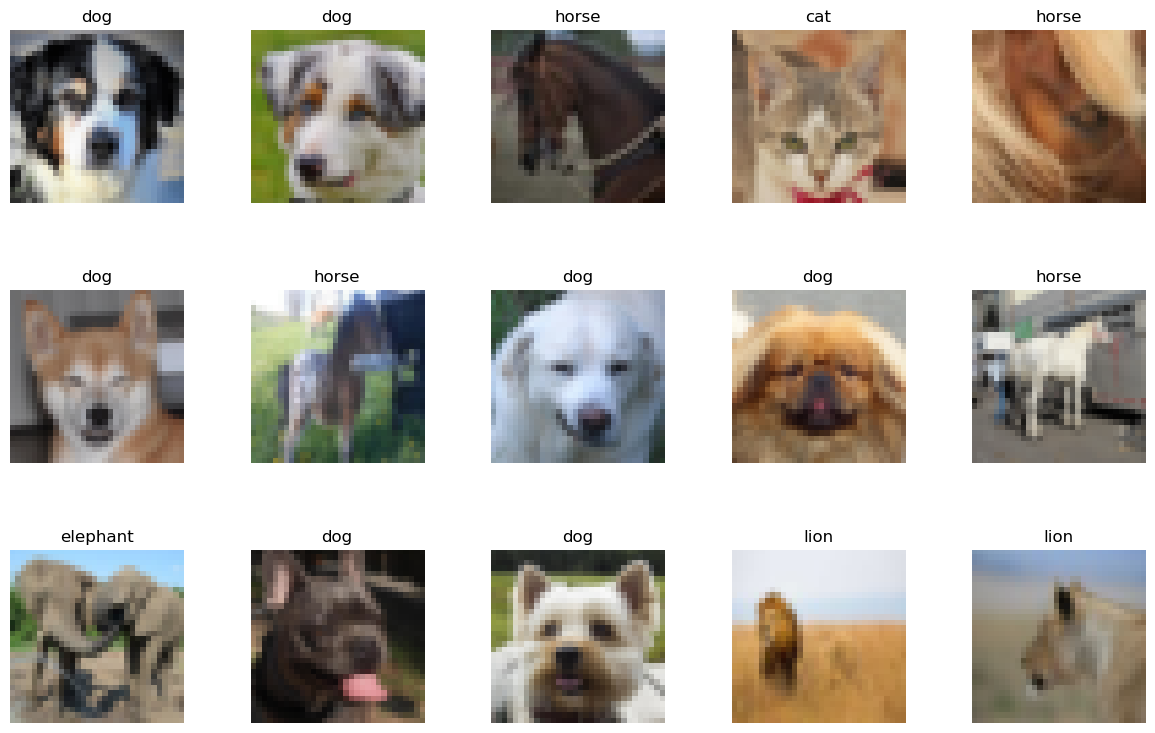

In [8]:
import random
import matplotlib.pyplot as plt

r, c = 3, 5
plt.figure(figsize=(c*3, r*3))
for row in range(r):
    for col in range(c):
        index = c*row + col
        plt.subplot(r, c, index + 1)
        ix = random.randint(0, len(trainset)-1)
        img, label = trainset[ix]

        # Reordenar las dimensiones del tensor para que imshow pueda mostrar la imagen
        img = img.permute(1, 2, 0)
        
        # Opcional: convertir el tensor a NumPy para asegurar compatibilidad
        img = img.cpu().numpy()

        plt.imshow(img)
        plt.axis('off')
        plt.title(classes[label])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

# **DEFINIMOS EL MODELO**

Como en el anterior laboratorio definimos el numero de entradas, la capa oculta y las salidas.

In [33]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in=32*32*3, H=100, D_out=5):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

ENTRENAMIENTO DEL MODELO

In [34]:
def fit(model, dataloader, epochs=50, log_each=10, weight_decay=0, early_stopping=10, lr=0.001, optimizer_class=torch.optim.Adam):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optimizer_class(model.parameters(), lr=lr, weight_decay=weight_decay)

    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs + 1):
        _l, _acc = [], []
        model.train()

        # Training loop
        for x_b, y_b in dataloader['train']:
            x_b, y_b = x_b.cuda().view(-1, 32*32*3), y_b.cuda()

            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))

        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # Validation loop
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                x_b, y_b = x_b.cuda().view(-1, 32*32*3), y_b.cuda()

                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())

                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))

        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # Save best model
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")

        step += 1

        # Early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    # Load best model
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

In [35]:
model = build_model()
hist = fit(model, dataloader)

Mejor modelo guardado con acc 0.35635 en epoch 1
Mejor modelo guardado con acc 0.47864 en epoch 2
Mejor modelo guardado con acc 0.53580 en epoch 8
Mejor modelo guardado con acc 0.54399 en epoch 9
Mejor modelo guardado con acc 0.57281 en epoch 10
Epoch 10/50 loss 0.98481 acc 0.60435 val_loss 1.04623 val_acc 0.57281
Mejor modelo guardado con acc 0.58213 en epoch 13
Mejor modelo guardado con acc 0.59375 en epoch 16
Epoch 20/50 loss 0.83340 acc 0.67017 val_loss 1.08764 val_acc 0.58117
Mejor modelo guardado con acc 0.59909 en epoch 23
Mejor modelo guardado con acc 0.60093 en epoch 24
Mejor modelo guardado con acc 0.60281 en epoch 27
Mejor modelo guardado con acc 0.60424 en epoch 30
Epoch 30/50 loss 0.70385 acc 0.71592 val_loss 1.06933 val_acc 0.60424
Mejor modelo guardado con acc 0.61784 en epoch 36
Epoch 40/50 loss 0.57940 acc 0.76836 val_loss 1.18285 val_acc 0.58057
Entrenamiento detenido en epoch 46 por no mejorar en 10 epochs seguidas


C:\Users\asus\AppData\Local\Temp\ipykernel_1172\3968310046.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


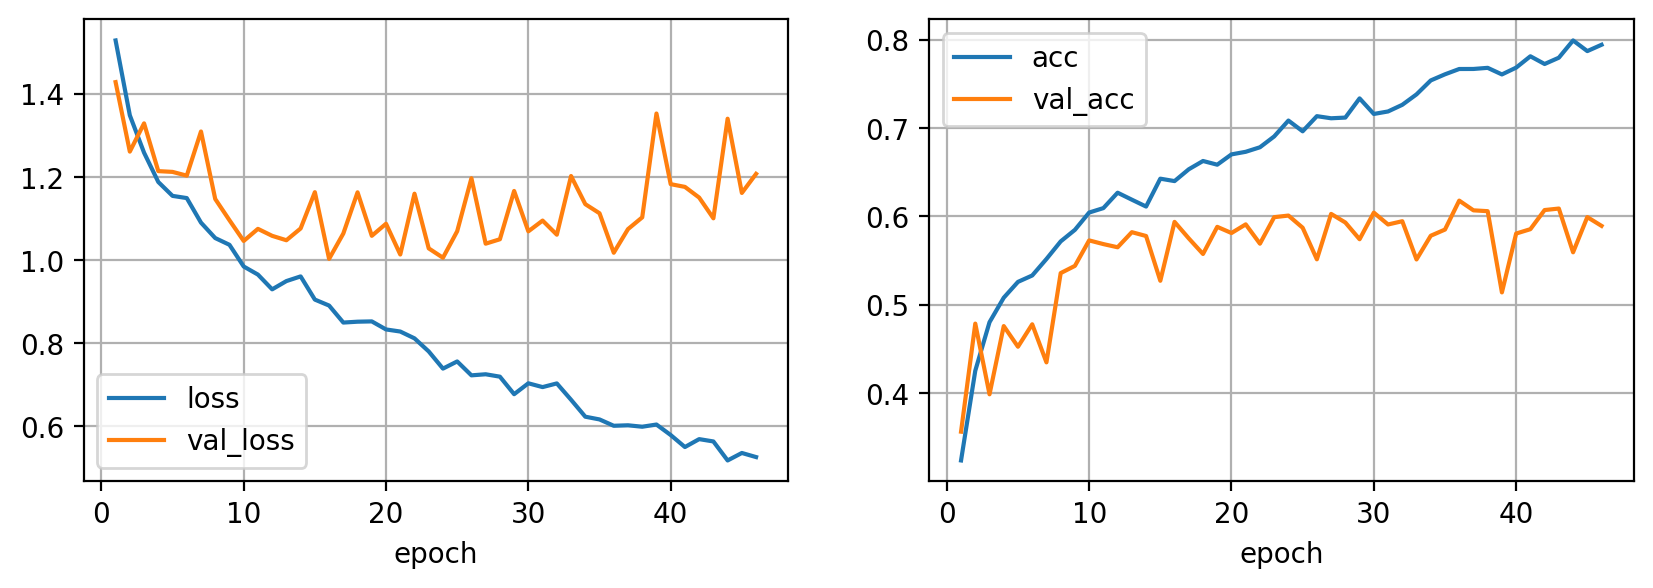

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

# **HACEMOS USO DE LOS DISTINTOS CASOS DE REGULARIZACION**

Aqui realizaremos la comparacion del uso de distintos casos de regularizacion vistos en clase y graficas comparativa.

# **REGULARIZACION L2**

Consiste en agregar un termino de penalizacion a la funcion de perdida del modelo.

In [37]:
model = build_model()
hist = fit(model, dataloader, weight_decay=0.01)

Mejor modelo guardado con acc 0.40223 en epoch 1
Mejor modelo guardado con acc 0.42219 en epoch 2
Mejor modelo guardado con acc 0.44852 en epoch 3
Mejor modelo guardado con acc 0.50074 en epoch 5
Mejor modelo guardado con acc 0.52582 en epoch 6
Mejor modelo guardado con acc 0.52894 en epoch 8
Mejor modelo guardado con acc 0.54682 en epoch 9
Epoch 10/50 loss 1.08221 acc 0.55757 val_loss 1.17171 val_acc 0.51284
Mejor modelo guardado con acc 0.57843 en epoch 14
Epoch 20/50 loss 0.96094 acc 0.61543 val_loss 1.36022 val_acc 0.42290
Entrenamiento detenido en epoch 24 por no mejorar en 10 epochs seguidas


C:\Users\asus\AppData\Local\Temp\ipykernel_1172\3968310046.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


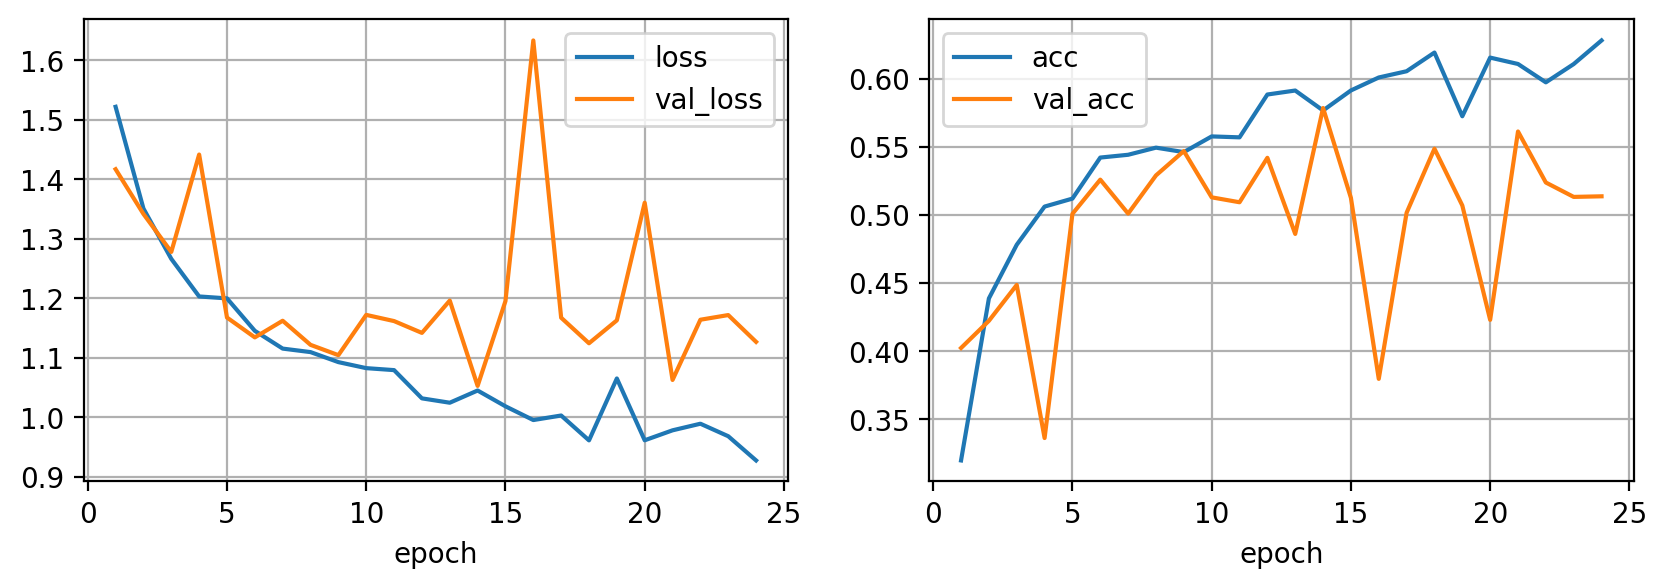

In [38]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

# **EARLY STOPPING**

Consiste en monitorear el rendimiento del modelo en un conjunto de datos de validacion y detener el entrenamiento cuando el rendimiento deja de mejorar.

In [42]:
def fit(model, dataloader, epochs=60, log_each=10, weight_decay=0, early_stopping=0, lr=0.001, optimizer_class=torch.optim.Adam):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optimizer_class(model.parameters(), lr=lr, weight_decay=weight_decay)

    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs + 1):
        _l, _acc = [], []
        model.train()

        # Training loop
        for x_b, y_b in dataloader['train']:
            x_b, y_b = x_b.cuda().view(-1, 32*32*3), y_b.cuda()

            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))

        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # Validation loop
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                x_b, y_b = x_b.cuda().view(-1, 32*32*3), y_b.cuda()

                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())

                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))

        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # Save best model
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")

        step += 1

        # Early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    # Load best model
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

In [43]:
model = build_model()
hist = fit(model, dataloader, early_stopping=20)

Mejor modelo guardado con acc 0.35831 en epoch 1
Mejor modelo guardado con acc 0.38879 en epoch 2
Mejor modelo guardado con acc 0.49514 en epoch 3
Mejor modelo guardado con acc 0.53682 en epoch 6
Mejor modelo guardado con acc 0.55308 en epoch 7
Epoch 10/60 loss 0.98427 acc 0.60615 val_loss 1.07637 val_acc 0.55250
Mejor modelo guardado con acc 0.57873 en epoch 11
Mejor modelo guardado con acc 0.59595 en epoch 12
Mejor modelo guardado con acc 0.60453 en epoch 13
Epoch 20/60 loss 0.80912 acc 0.67588 val_loss 1.10197 val_acc 0.57603
Epoch 30/60 loss 0.72054 acc 0.70796 val_loss 1.05921 val_acc 0.59664
Mejor modelo guardado con acc 0.60568 en epoch 31
Epoch 40/60 loss 0.62713 acc 0.75405 val_loss 1.17550 val_acc 0.58504
Mejor modelo guardado con acc 0.60734 en epoch 45
Mejor modelo guardado con acc 0.62585 en epoch 49
Epoch 50/60 loss 0.47076 acc 0.81953 val_loss 1.15802 val_acc 0.60172
Epoch 60/60 loss 0.40275 acc 0.84233 val_loss 1.40323 val_acc 0.57760


C:\Users\asus\AppData\Local\Temp\ipykernel_1172\3182733219.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


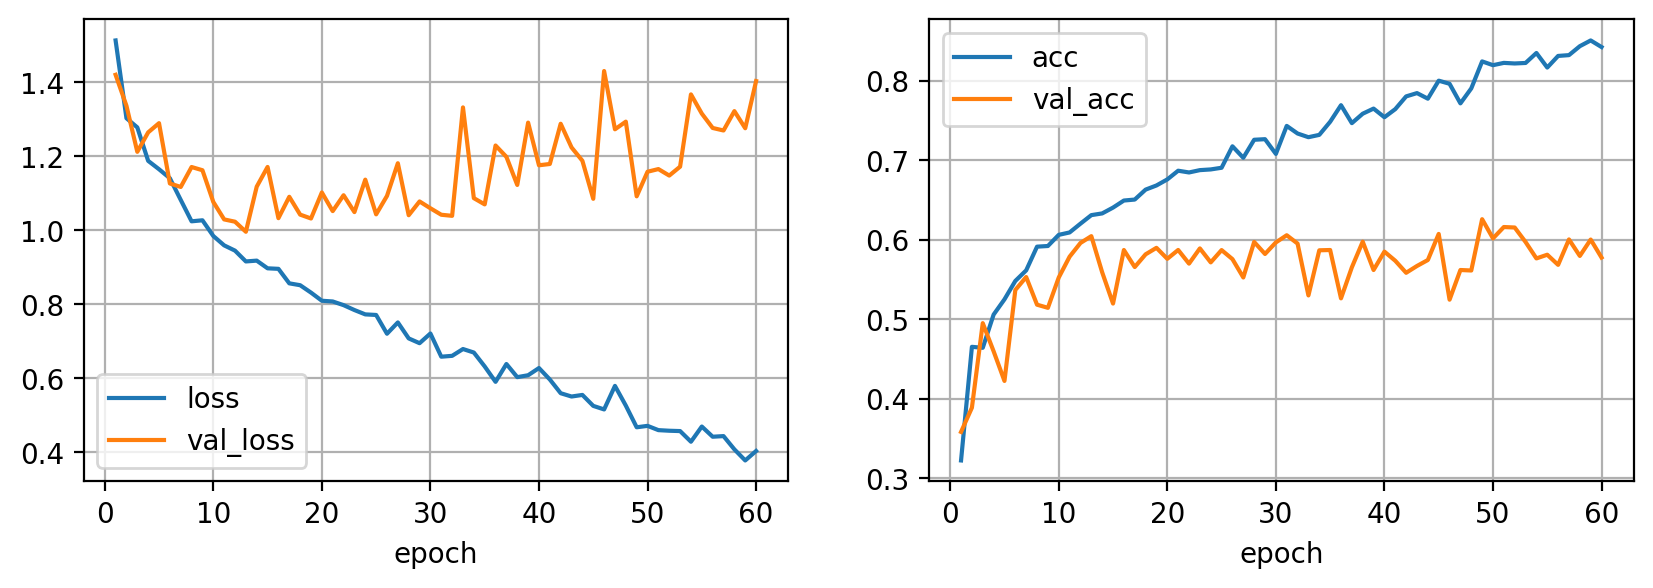

In [44]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

# **DROPOUT**

Consiste en desactivar aleatoriamente un porcentaje de neuronas durante cada paso del entrenamiento. Si dropout rate = 0.5, el modelo ignora la mitad de las neuronas de una capa. Esto fuerza a la red a no depender demasiado de un conjunto particular de neuronas. En lugar de que la red se vuelva "codependiente" de ciertas neuronas, se ve obligada a encontrar rutas de información más robustas y redundantes, lo que hace que cada neurona sea más independiente y capaz de aprender características útiles por sí sola.

In [45]:
def build_model(D_in=32*32*3, H=100, D_out=10, p=0):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, D_out)
    ).cuda()

In [46]:
model = build_model(p=0.5)
hist = fit(model, dataloader)

Mejor modelo guardado con acc 0.19614 en epoch 1
Mejor modelo guardado con acc 0.39814 en epoch 2
Mejor modelo guardado con acc 0.43742 en epoch 4
Mejor modelo guardado con acc 0.46043 en epoch 8
Mejor modelo guardado con acc 0.47244 en epoch 10
Epoch 10/60 loss 1.36008 acc 0.41431 val_loss 1.25528 val_acc 0.47244
Mejor modelo guardado con acc 0.53901 en epoch 11
Epoch 20/60 loss 1.27265 acc 0.45581 val_loss 1.17741 val_acc 0.49576
Mejor modelo guardado con acc 0.54106 en epoch 27
Mejor modelo guardado con acc 0.54156 en epoch 30
Epoch 30/60 loss 1.21995 acc 0.47036 val_loss 1.15680 val_acc 0.54156
Mejor modelo guardado con acc 0.55620 en epoch 31
Mejor modelo guardado con acc 0.58491 en epoch 32
Epoch 40/60 loss 1.18827 acc 0.48560 val_loss 1.14569 val_acc 0.51608
Epoch 50/60 loss 1.18475 acc 0.48623 val_loss 1.12266 val_acc 0.51477
Epoch 60/60 loss 1.17982 acc 0.49180 val_loss 1.09834 val_acc 0.51577


C:\Users\asus\AppData\Local\Temp\ipykernel_1172\3182733219.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


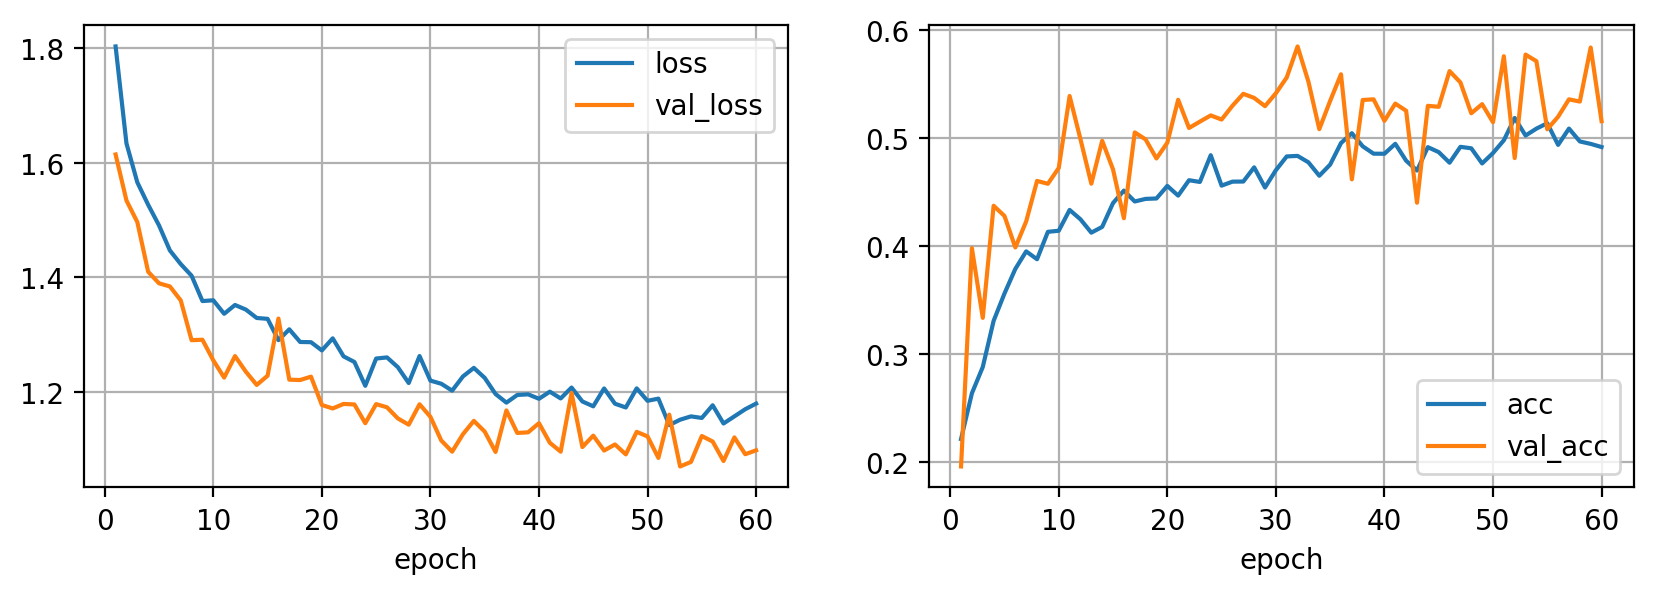

In [47]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

# **USAR MAS DATOS**

Hacer uso de mas datos reducira el overfitting.

In [48]:
train_root_dir = 'C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Laboratorios/Laboratorio6/train'
val_root_dir = 'C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Laboratorios/Laboratorio6/val'

In [49]:
trainset = ImageFolder(root=train_root_dir, transform=transform)
valset = ImageFolder(root=val_root_dir, transform=transform)

classes = trainset.classes

In [50]:
print(f"Clases detectadas: {classes}")
print(f"Imágenes de entrenamiento: {len(trainset)}")
print(f"Imágenes de validación: {len(valset)}")

Clases detectadas: ['cat', 'dog', 'elephant', 'horse', 'lion']
Imágenes de entrenamiento: 13474
Imágenes de validación: 1497


In [51]:
dataloader = {
    'train': torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True),
    'val': torch.utils.data.DataLoader(valset, batch_size=1000, shuffle=False)
}

Verificamos nuevamente.

In [52]:
model = build_model()
hist = fit(model, dataloader, early_stopping=10)

Mejor modelo guardado con acc 0.44799 en epoch 1
Mejor modelo guardado con acc 0.52861 en epoch 2
Mejor modelo guardado con acc 0.56567 en epoch 3
Mejor modelo guardado con acc 0.58073 en epoch 4
Mejor modelo guardado con acc 0.60084 en epoch 6
Mejor modelo guardado con acc 0.62650 en epoch 7
Mejor modelo guardado con acc 0.63452 en epoch 10
Epoch 10/60 loss 0.90930 acc 0.63041 val_loss 0.93125 val_acc 0.63452
Mejor modelo guardado con acc 0.64032 en epoch 16
Mejor modelo guardado con acc 0.65738 en epoch 17
Mejor modelo guardado con acc 0.66256 en epoch 20
Epoch 20/60 loss 0.76917 acc 0.69226 val_loss 0.87701 val_acc 0.66256
Mejor modelo guardado con acc 0.67308 en epoch 25
Mejor modelo guardado con acc 0.67663 en epoch 29
Epoch 30/60 loss 0.65526 acc 0.74021 val_loss 0.94509 val_acc 0.64022
Entrenamiento detenido en epoch 39 por no mejorar en 10 epochs seguidas


C:\Users\asus\AppData\Local\Temp\ipykernel_1172\3182733219.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


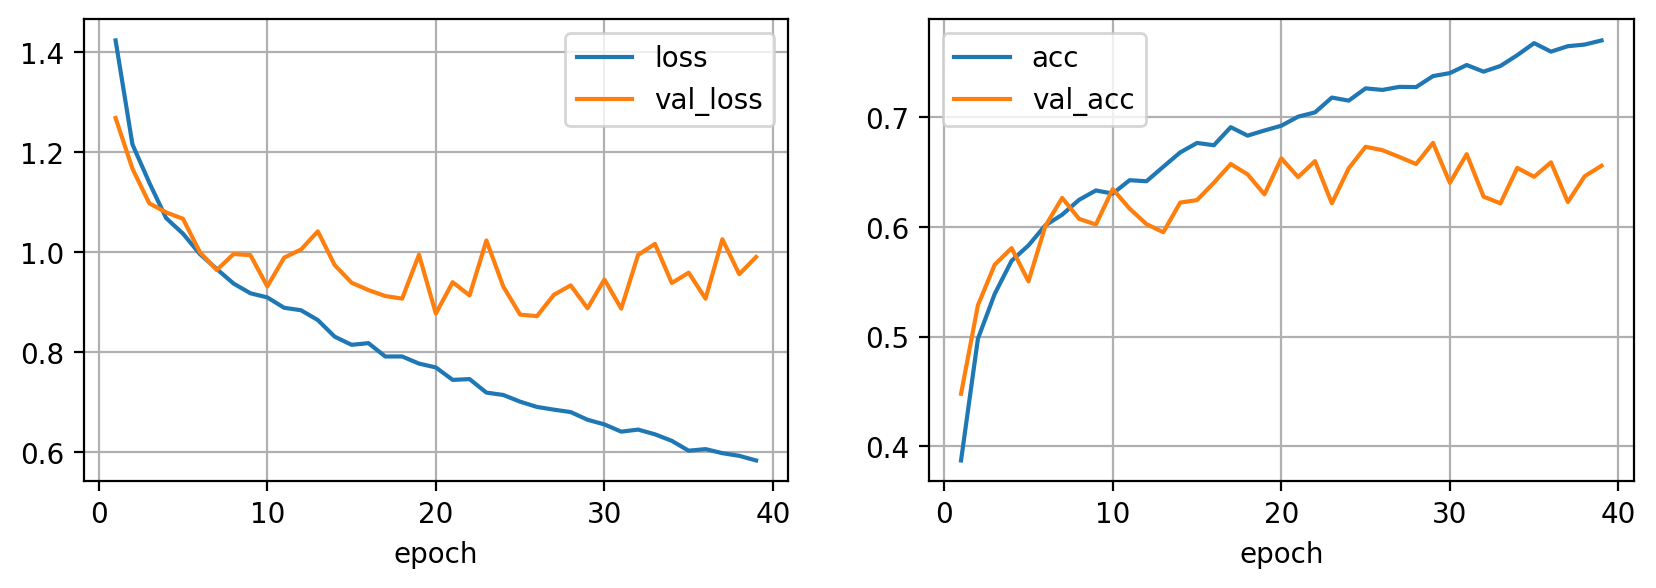

In [53]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()